In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('placement.csv')

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [7]:
import matplotlib.pyplot as plt


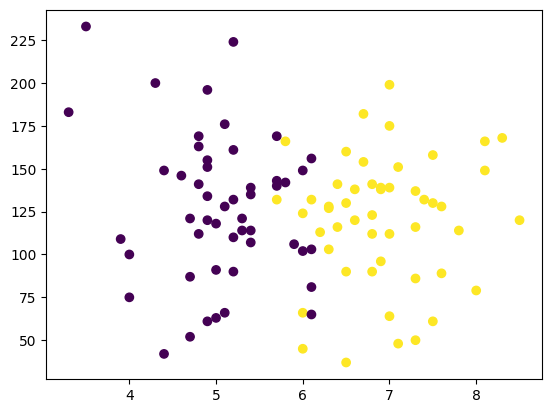

In [8]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

In [9]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [10]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [11]:
y.shape

(100,)

In [12]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [13]:
X_train

,cgpa,iq
32,7.0,139.0
36,5.7,140.0
24,4.7,121.0
90,7.3,86.0
63,6.3,128.0
...,...,...
4,5.8,142.0
99,6.2,113.0
11,6.9,138.0
20,6.6,120.0


In [14]:
y_train

32    1
36    0
24    0
90    1
63    1
     ..
4     0
99    1
11    1
20    1
67    0
Name: placement, Length: 90, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [16]:
X_train = scaler.fit_transform(X_train)

In [17]:
X_train

array([[ 0.88549724,  0.37773844],
       [-0.25802569,  0.40235571],
       [-1.13765871, -0.06537255],
       [ 1.14938715, -0.92697724],
       [ 0.26975413,  0.10694839],
       [ 1.32531376, -1.54240916],
       [-0.7858055 ,  1.28857768],
       [-0.96173211,  1.78092322],
       [ 0.53364403,  0.35312116],
       [ 1.14938715,  0.32850388],
       [-0.6978422 , -0.33616259],
       [-1.04969541,  1.11625674],
       [-0.96173211,  0.77161487],
       [ 0.88549724,  1.85477505],
       [ 0.09382752, -1.05006362],
       [ 0.00586422, -0.53310081],
       [ 0.62160734,  0.74699759],
       [-1.40154862, -2.01013742],
       [ 0.00586422, -1.41932277],
       [ 0.09382752,  0.2054175 ],
       [-0.25802569,  0.2054175 ],
       [-0.52191559, -0.23769348],
       [-0.17006238,  1.04240491],
       [-0.7858055 , -1.41932277],
       [ 1.85309357,  0.62391121],
       [ 0.62160734,  1.43628134],
       [ 0.44568073, -2.1332238 ],
       [ 1.23735045,  0.2054175 ],
       [-0.96173211,

In [18]:
X_test = scaler.transform(X_test)
X_test

array([[-1.75340183, -0.58233536],
       [-1.13765871, -0.90235996],
       [ 0.70957064, -0.28692804],
       [-0.25802569,  0.47620754],
       [ 0.88549724, -1.46855733],
       [-0.52191559,  0.37773844],
       [-0.6978422 ,  0.91931853],
       [ 1.85309357,  1.04240491],
       [ 0.44568073,  0.15618295],
       [ 0.26975413,  0.08233111]])

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
clf = LogisticRegression()

In [21]:
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred= clf.predict(X_test)
y_pred

array([0, 0, 1, 0, 1, 0, 0, 1, 1, 1])

In [23]:
y_test

18    0
23    0
93    1
6     0
64    1
12    0
47    0
65    1
57    1
70    1
Name: placement, dtype: int64

In [24]:
from sklearn.metrics import accuracy_score



In [25]:
accuracy_score(y_test, y_pred)

1.0

In [26]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

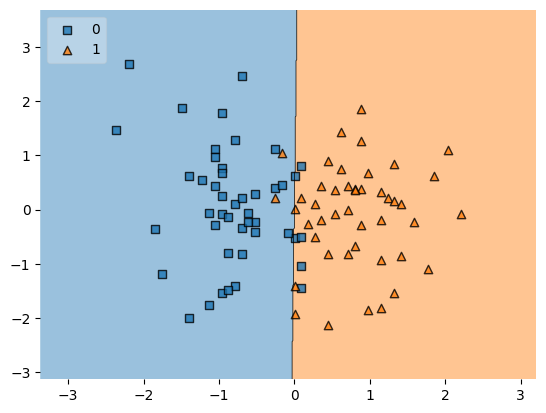

In [27]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [28]:
import pickle

In [ ]:
pickle.dump(clf, open('model.pkl','wb')) #wb = write-binary